# 🎯 Credit Scoring — Notebook 03: Optuna Bayesian Hyperparameter Optimization
**Author:** Abu Jafar Sisty  
**Conference:** COMPAS 2026 — IEEE 3rd International Conference, University of Dhaka  
**Dataset:** Give Me Some Credit — 150,000 records

---
**Objective:** Use Optuna (Bayesian Optimization) to find best hyperparameters for all 4 models, compare with GridSearchCV results, achieve highest possible AUC

## 1️⃣ Install & Import Libraries

In [1]:
!pip install optuna pandas numpy matplotlib seaborn scikit-learn xgboost


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install optuna


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import pickle
import json
import warnings
import os
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)

SEED = 42
np.random.seed(SEED)

os.makedirs('../figures', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print('✅ Libraries loaded!')
print(f'   Optuna version: {optuna.__version__}')

✅ Libraries loaded!
   Optuna version: 4.9.0


## 2️⃣ Load, Clean & Feature Engineering
(Same as Notebook 01 & 02)

In [4]:
df = pd.read_csv('../data/raw/cs-training.csv', index_col=0)

# --- Cleaning ---
df = df[(df['age'] >= 18) & (df['age'] <= 100)]
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(0, inplace=True)
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)
for col in ['DebtRatio', 'MonthlyIncome']:
    df[col] = df[col].clip(0, df[col].quantile(0.99))
for col in ['NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTime60-89DaysPastDueNotWorse',
            'NumberOfTimes90DaysLate']:
    df[col] = df[col].clip(0, 10)

# --- Feature Engineering ---
df['TotalTimesPastDue'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate']
)
df['WeightedLatePay'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] * 1 +
    df['NumberOfTime60-89DaysPastDueNotWorse'] * 2 +
    df['NumberOfTimes90DaysLate'] * 3
)
df['MonthlyDebt']        = df['DebtRatio'] * df['MonthlyIncome']
df['NetMonthlyIncome']   = df['MonthlyIncome'] - df['MonthlyDebt']
df['IncomePerDependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)
df['DebtPerDependent']   = df['MonthlyDebt']   / (df['NumberOfDependents'] + 1)
df['HighUtilization']    = (df['RevolvingUtilizationOfUnsecuredLines'] > 0.7).astype(int)
df['MaxedOut']           = (df['RevolvingUtilizationOfUnsecuredLines'] > 0.95).astype(int)
df['IsYoung']            = (df['age'] < 30).astype(int)
df['IsSenior']           = (df['age'] > 60).astype(int)
df['AgeBucket']          = pd.cut(df['age'], bins=[0,25,35,45,55,65,100], labels=[0,1,2,3,4,5]).astype(int)
df['HasLatePay']         = (df['TotalTimesPastDue'] > 0).astype(int)
df['HasSeriousLatePay']  = (df['NumberOfTimes90DaysLate'] > 0).astype(int)
df['HasOpenLoans']       = (df['NumberOfOpenCreditLinesAndLoans'] > 0).astype(int)
df['HasRealEstate']      = (df['NumberRealEstateLoansOrLines'] > 0).astype(int)
df['IsNegativeCash']     = (df['NetMonthlyIncome'] < 0).astype(int)
df['UtilizationXLatePay'] = df['RevolvingUtilizationOfUnsecuredLines'] * df['TotalTimesPastDue']
df['DebtRatioXAge']      = df['DebtRatio'] * df['age']

# ✅ NaN & Infinite values fix
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median(numeric_only=True))
print(f'NaN after fix: {df.isnull().sum().sum()}')  # 0 হওয়া উচিত

# --- Split ---
target_col = 'SeriousDlqin2yrs'
X = df.drop(columns=[target_col])
y = df[target_col]
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, random_state=SEED, stratify=y.values
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

scale_weight = (y.values == 0).sum() / (y.values == 1).sum()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f'✅ Dataset ready: {X_train.shape[0]:,} train, {X_test.shape[0]:,} test')
print(f'Total features  : {len(feature_names)}')
print(f'scale_pos_weight: {scale_weight:.2f}')

NaN after fix: 0
✅ Dataset ready: 119,988 train, 29,998 test
Total features  : 28
scale_pos_weight: 13.96


## 3️⃣ Load Previous Results (Baseline & GridSearchCV)

In [5]:
baseline_df = pd.read_csv('../outputs/baseline_results.csv')
gridsearch_df = pd.read_csv('../outputs/tuned_results.csv')

print('=== Baseline Results ===')
print(baseline_df[['Model','AUC']].to_string(index=False))
print('\n=== GridSearchCV Results ===')
print(gridsearch_df[['Model','AUC']].to_string(index=False))

=== Baseline Results ===
              Model    AUC
  Gradient Boosting 0.8709
Logistic Regression 0.8678
            XGBoost 0.8503
      Random Forest 0.8427

=== GridSearchCV Results ===
              Model    AUC
            XGBoost 0.8728
  Gradient Boosting 0.8719
      Random Forest 0.8690
Logistic Regression 0.8679


## 4️⃣ Optuna Objective Functions (1 per model)

In [6]:
# --- Logistic Regression Objective ---
def objective_lr(trial):
    C       = trial.suggest_float('C', 1e-4, 100, log=True)
    solver  = trial.suggest_categorical('solver', ['liblinear', 'lbfgs', 'saga'])
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    if solver == 'lbfgs' and penalty == 'l1':
        penalty = 'l2'  # lbfgs doesn't support l1
    model = LogisticRegression(
        C=C, solver=solver, penalty=penalty,
        max_iter=1000, class_weight='balanced', random_state=SEED
    )
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

# --- Random Forest Objective ---
def objective_rf(trial):
    n_estimators      = trial.suggest_int('n_estimators', 100, 600)
    max_depth         = trial.suggest_int('max_depth', 5, 40)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 15)
    min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    model = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
        max_features=max_features, class_weight='balanced',
        random_state=SEED, n_jobs=-1
    )
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

# --- Gradient Boosting Objective ---
def objective_gbm(trial):
    n_estimators   = trial.suggest_int('n_estimators', 100, 600)
    learning_rate  = trial.suggest_float('learning_rate', 0.005, 0.3, log=True)
    max_depth      = trial.suggest_int('max_depth', 2, 8)
    subsample      = trial.suggest_float('subsample', 0.6, 1.0)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    max_features   = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    model = GradientBoostingClassifier(
        n_estimators=n_estimators, learning_rate=learning_rate,
        max_depth=max_depth, subsample=subsample,
        min_samples_split=min_samples_split, max_features=max_features,
        random_state=SEED
    )
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

# --- XGBoost Objective ---
def objective_xgb(trial):
    n_estimators       = trial.suggest_int('n_estimators', 100, 800)
    learning_rate      = trial.suggest_float('learning_rate', 0.005, 0.3, log=True)
    max_depth          = trial.suggest_int('max_depth', 2, 10)
    subsample          = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree   = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    min_child_weight   = trial.suggest_int('min_child_weight', 1, 10)
    gamma              = trial.suggest_float('gamma', 0, 0.5)
    reg_alpha          = trial.suggest_float('reg_alpha', 1e-4, 10, log=True)
    reg_lambda         = trial.suggest_float('reg_lambda', 1e-4, 10, log=True)
    model = XGBClassifier(
        n_estimators=n_estimators, learning_rate=learning_rate,
        max_depth=max_depth, subsample=subsample,
        colsample_bytree=colsample_bytree, min_child_weight=min_child_weight,
        gamma=gamma, reg_alpha=reg_alpha, reg_lambda=reg_lambda,
        scale_pos_weight=scale_weight,
        eval_metric='logloss', verbosity=0,
        random_state=SEED, n_jobs=-1
    )
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

objectives = {
    'Logistic Regression': objective_lr,
    'Random Forest':       objective_rf,
    'Gradient Boosting':   objective_gbm,
    'XGBoost':             objective_xgb
}

print('✅ Optuna objective functions defined!')

✅ Optuna objective functions defined!


## 5️⃣ Run Optuna Studies (Bayesian Optimization)
⏱️ ~10-20 minutes total

In [7]:
N_TRIALS = 50  # increase to 100 for better results (but slower)

optuna_results   = []
best_params_all  = {}
optuna_models    = {}

for name, objective in objectives.items():
    print(f'\n🔍 Optuna tuning: {name} ({N_TRIALS} trials) ...')

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

    best_params = study.best_params
    best_cv_auc = study.best_value
    best_params_all[name] = best_params

    print(f'   Best CV AUC  : {best_cv_auc:.4f}')
    print(f'   Best Params  : {best_params}')

    # Fix lbfgs + l1 issue for LR
    if name == 'Logistic Regression':
        if best_params.get('solver') == 'lbfgs' and best_params.get('penalty') == 'l1':
            best_params['penalty'] = 'l2'

    # Build best model
    if name == 'Logistic Regression':
        best_model = LogisticRegression(
            **best_params, max_iter=1000, class_weight='balanced', random_state=SEED
        )
        best_model.fit(X_train_scaled, y_train)
        y_pred = best_model.predict(X_test_scaled)
        y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

    elif name == 'Random Forest':
        best_model = RandomForestClassifier(
            **best_params, class_weight='balanced', random_state=SEED, n_jobs=-1
        )
        best_model.fit(X_train, y_train)
        y_pred = best_model.predict(X_test)
        y_prob = best_model.predict_proba(X_test)[:, 1]

    elif name == 'Gradient Boosting':
        best_model = GradientBoostingClassifier(
            **best_params, random_state=SEED
        )
        best_model.fit(X_train, y_train)
        y_pred = best_model.predict(X_test)
        y_prob = best_model.predict_proba(X_test)[:, 1]

    elif name == 'XGBoost':
        best_model = XGBClassifier(
            **best_params, scale_pos_weight=scale_weight,
            eval_metric='logloss', verbosity=0, random_state=SEED, n_jobs=-1
        )
        best_model.fit(X_train, y_train)
        y_pred = best_model.predict(X_test)
        y_prob = best_model.predict_proba(X_test)[:, 1]

    optuna_models[name] = best_model

    optuna_results.append({
        'Model':       name,
        'AUC':         round(roc_auc_score(y_test, y_prob), 4),
        'Accuracy':    round(accuracy_score(y_test, y_pred), 4),
        'Precision':   round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'Recall':      round(recall_score(y_test, y_pred, average='weighted'), 4),
        'F1-Score':    round(f1_score(y_test, y_pred, average='weighted'), 4),
        'Best CV AUC': round(best_cv_auc, 4)
    })
    print(f'   Test AUC     : {optuna_results[-1]["AUC"]:.4f}')

optuna_df = pd.DataFrame(optuna_results).sort_values('AUC', ascending=False)
optuna_df.to_csv('../outputs/optuna_results.csv', index=False)

print('\n===== OPTUNA RESULTS =====')
print(optuna_df.to_string(index=False))


🔍 Optuna tuning: Logistic Regression (50 trials) ...
   Best CV AUC  : 0.8587
   Best Params  : {'C': 0.0192982820026737, 'solver': 'liblinear', 'penalty': 'l1'}
   Test AUC     : 0.8679

🔍 Optuna tuning: Random Forest (50 trials) ...
   Best CV AUC  : 0.8608
   Best Params  : {'n_estimators': 172, 'max_depth': 9, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 'log2'}
   Test AUC     : 0.8700

🔍 Optuna tuning: Gradient Boosting (50 trials) ...
   Best CV AUC  : 0.8644
   Best Params  : {'n_estimators': 508, 'learning_rate': 0.02077133354404949, 'max_depth': 5, 'subsample': 0.6779458726707359, 'min_samples_split': 19, 'max_features': 'log2'}
   Test AUC     : 0.8731

🔍 Optuna tuning: XGBoost (50 trials) ...
   Best CV AUC  : 0.8642
   Best Params  : {'n_estimators': 388, 'learning_rate': 0.020967882837031732, 'max_depth': 4, 'subsample': 0.6379523960155078, 'colsample_bytree': 0.5378982092113247, 'min_child_weight': 3, 'gamma': 0.0629801893983079, 'reg_alpha': 0.003797

## 6️⃣ Save Best Model

In [8]:
best_model_name = optuna_df.iloc[0]['Model']
best_model_obj  = optuna_models[best_model_name]

with open('../models/best_credit_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)
with open('../models/best_params_optuna.pkl', 'wb') as f:
    pickle.dump(best_params_all, f)
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('../models/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print(f'✅ Best model saved : {best_model_name}')
print(f'   AUC             : {optuna_df.iloc[0]["AUC"]}')

✅ Best model saved : XGBoost
   AUC             : 0.8734


## 7️⃣ 3-Way Comparison: Baseline vs GridSearchCV vs Optuna

In [9]:
comp3 = baseline_df[['Model','AUC']].copy().rename(columns={'AUC':'Baseline AUC'})
gs    = gridsearch_df[['Model','AUC']].copy().rename(columns={'AUC':'GridSearch AUC'})
opt   = optuna_df[['Model','AUC']].copy().rename(columns={'AUC':'Optuna AUC'})

comp3 = comp3.merge(gs, on='Model').merge(opt, on='Model')
comp3['Optuna Improvement (%)'] = (
    (comp3['Optuna AUC'] - comp3['Baseline AUC']) / comp3['Baseline AUC'] * 100
).round(2)
comp3 = comp3.sort_values('Optuna AUC', ascending=False)
comp3.to_csv('../outputs/three_way_comparison.csv', index=False)

print('===== 3-WAY COMPARISON =====')
print(comp3.to_string(index=False))

===== 3-WAY COMPARISON =====
              Model  Baseline AUC  GridSearch AUC  Optuna AUC  Optuna Improvement (%)
            XGBoost        0.8503          0.8728      0.8734                    2.72
  Gradient Boosting        0.8709          0.8719      0.8731                    0.25
      Random Forest        0.8427          0.8690      0.8700                    3.24
Logistic Regression        0.8678          0.8679      0.8679                    0.01


## 8️⃣ AUC Comparison Chart (Baseline vs GridSearch vs Optuna)

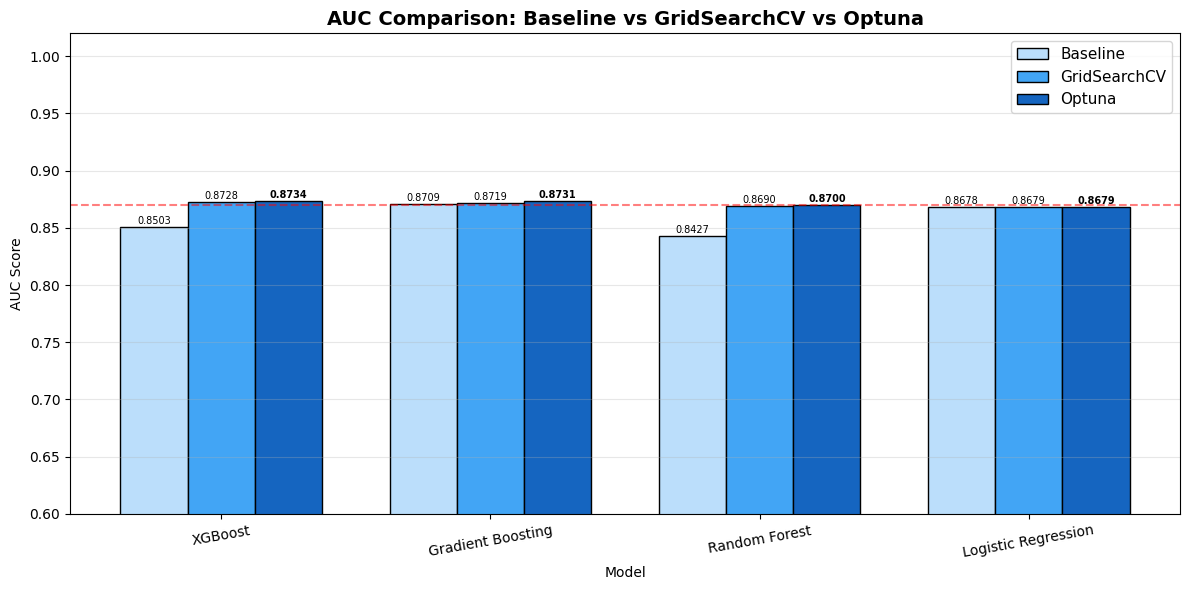

✅ Saved: figures/optuna_auc_comparison.png


In [10]:
models_list = comp3['Model'].tolist()
x = np.arange(len(models_list))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - width, comp3['Baseline AUC'],   width, label='Baseline',     color='#BBDEFB', edgecolor='black')
b2 = ax.bar(x,         comp3['GridSearch AUC'], width, label='GridSearchCV', color='#42A5F5', edgecolor='black')
b3 = ax.bar(x + width, comp3['Optuna AUC'],     width, label='Optuna',       color='#1565C0', edgecolor='black')

for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7)
for bar in b3:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=10, fontsize=10)
ax.set_ylim(0.6, 1.02)
ax.set_title('AUC Comparison: Baseline vs GridSearchCV vs Optuna', fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('AUC Score')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.87, color='red', linestyle='--', alpha=0.5, label='0.87 threshold')
plt.tight_layout()
plt.savefig('../figures/optuna_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/optuna_auc_comparison.png')

## 9️⃣ Best Model — ROC Curve & Confusion Matrix

In [3]:
best_name  = optuna_df.iloc[0]['Model']
best_model = optuna_models[best_name]
X_te_best  = X_test_scaled if best_name == 'Logistic Regression' else X_test

y_pred_best = best_model.predict(X_te_best)
y_prob_best = best_model.predict_proba(X_te_best)[:, 1]
auc_val     = roc_auc_score(y_test, y_prob_best)
fpr, tpr, _ = roc_curve(y_test, y_prob_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='#1565C0', linewidth=2.5, label=f'AUC = {auc_val:.4f}')
axes[0].plot([0,1],[0,1],'k--', linewidth=1)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#1565C0')
axes[0].set_title(f'ROC Curve — {best_name} (Optuna Tuned)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=12)
axes[0].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Default','Default'],
            yticklabels=['No Default','Default'])
axes[1].set_title(f'Confusion Matrix — {best_name} (Optuna)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../figures/optuna_best_model_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Best Model: {best_name} | AUC: {auc_val:.4f}')
print('✅ Saved: figures/optuna_best_model_roc.png')

NameError: name 'optuna_df' is not defined

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Default','Default'],
            yticklabels=['No Default','Default'])
ax.set_title(f'Confusion Matrix — {best_name} (Optuna)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../figures/optuna_best_model_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Saved: figures/optuna_best_model_confusion_matrix.png')

## 🔟 Optuna Optimization History Plot

Re-running XGBoost study for visualization...


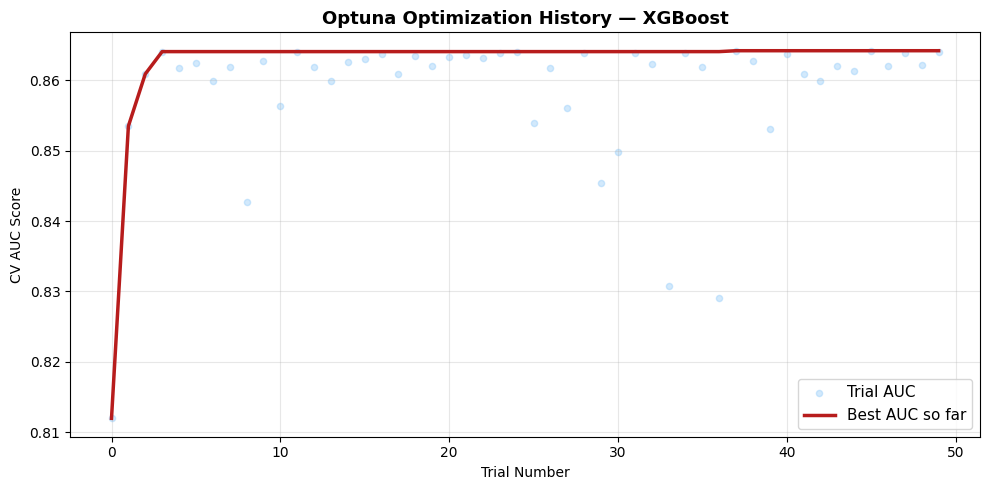

✅ Saved: figures/optuna_history.png


In [12]:
# Re-run XGBoost study to get history (for visualization)
print('Re-running XGBoost study for visualization...')
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=False)

# Plot optimization history
trial_nums = [t.number for t in study_xgb.trials]
trial_vals = [t.value for t in study_xgb.trials]
best_vals  = [max(trial_vals[:i+1]) for i in range(len(trial_vals))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(trial_nums, trial_vals, alpha=0.4, color='#90CAF9', s=20, label='Trial AUC')
ax.plot(trial_nums, best_vals, color='#B71C1C', linewidth=2.5, label='Best AUC so far')
ax.set_title('Optuna Optimization History — XGBoost', fontsize=13, fontweight='bold')
ax.set_xlabel('Trial Number')
ax.set_ylabel('CV AUC Score')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/optuna_history.png')

## 1️⃣1️⃣ Updated Related Papers Comparison (Give Me Some Credit)

===== RELATED PAPERS COMPARISON (Give Me Some Credit) =====
                              Reference               Model    AUC  Year
          This Study (XGBoost + Optuna)             XGBoost 0.8734  2026
                  Alonso & Carbo (2021)        XGBoost + RF 0.8700  2021
                 Lessmann et al. (2015)      GBM + Ensemble 0.8680  2015
                   Monotonic NAM (2022)     Neural Additive 0.8600  2022
                  Bahnsen et al. (2015) LR (cost-sensitive) 0.8560  2015
Interpretable Selective Learning (2022)          LR Variant 0.8550  2022
                  Baesens et al. (2003)            SVM + NN 0.8400  2003


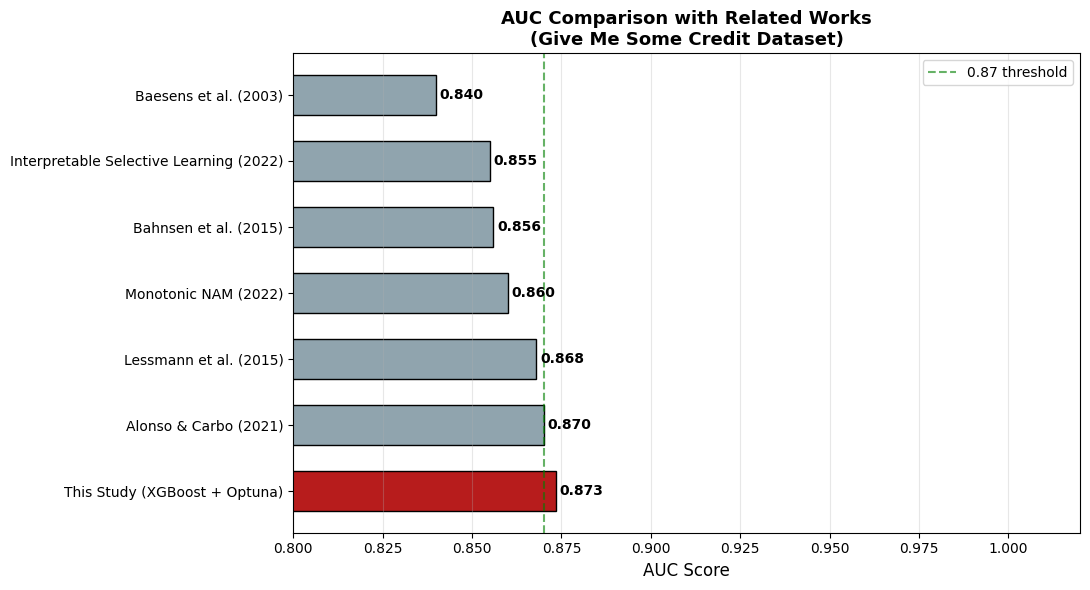

✅ Saved: figures/related_papers_comparison.png


In [13]:
best_auc = optuna_df.iloc[0]['AUC']

related = pd.DataFrame([
    {'Reference': 'This Study (XGBoost + Optuna)',          'Model': 'XGBoost',            'AUC': best_auc, 'Year': 2026, 'Dataset': 'Give Me Some Credit'},
    {'Reference': 'Alonso & Carbo (2021)',                  'Model': 'XGBoost + RF',        'AUC': 0.870,   'Year': 2021, 'Dataset': 'Give Me Some Credit'},
    {'Reference': 'Lessmann et al. (2015)',                 'Model': 'GBM + Ensemble',      'AUC': 0.868,   'Year': 2015, 'Dataset': 'Multiple Datasets'},
    {'Reference': 'Monotonic NAM (2022)',                   'Model': 'Neural Additive',     'AUC': 0.860,   'Year': 2022, 'Dataset': 'Give Me Some Credit'},
    {'Reference': 'Bahnsen et al. (2015)',                  'Model': 'LR (cost-sensitive)', 'AUC': 0.856,   'Year': 2015, 'Dataset': 'Give Me Some Credit'},
    {'Reference': 'Interpretable Selective Learning (2022)','Model': 'LR Variant',          'AUC': 0.855,   'Year': 2022, 'Dataset': 'Give Me Some Credit'},
    {'Reference': 'Baesens et al. (2003)',                  'Model': 'SVM + NN',            'AUC': 0.840,   'Year': 2003, 'Dataset': 'Multiple Datasets'},
]).sort_values('AUC', ascending=False)

related.to_csv('../outputs/related_papers_comparison.csv', index=False)

print('===== RELATED PAPERS COMPARISON (Give Me Some Credit) =====')
print(related[['Reference','Model','AUC','Year']].to_string(index=False))

# Chart
fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#B71C1C' if 'This Study' in r else '#90A4AE' for r in related['Reference']]
bars = ax.barh(related['Reference'], related['AUC'], color=colors, edgecolor='black', height=0.6)
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0.80, 1.02)
ax.set_title('AUC Comparison with Related Works\n(Give Me Some Credit Dataset)', fontsize=13, fontweight='bold')
ax.set_xlabel('AUC Score', fontsize=12)
ax.axvline(x=0.87, color='green', linestyle='--', alpha=0.6, label='0.87 threshold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/related_papers_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/related_papers_comparison.png')

## 1️⃣2️⃣ Best Hyperparameters Summary

In [14]:
print('===== BEST HYPERPARAMETERS (Optuna) =====')
for name, params in best_params_all.items():
    print(f'\n{name}:')
    for k, v in params.items():
        print(f'   {k}: {v}')

===== BEST HYPERPARAMETERS (Optuna) =====

Logistic Regression:
   C: 0.0192982820026737
   solver: liblinear
   penalty: l1

Random Forest:
   n_estimators: 172
   max_depth: 9
   min_samples_split: 12
   min_samples_leaf: 7
   max_features: log2

Gradient Boosting:
   n_estimators: 508
   learning_rate: 0.02077133354404949
   max_depth: 5
   subsample: 0.6779458726707359
   min_samples_split: 19
   max_features: log2

XGBoost:
   n_estimators: 388
   learning_rate: 0.020967882837031732
   max_depth: 4
   subsample: 0.6379523960155078
   colsample_bytree: 0.5378982092113247
   min_child_weight: 3
   gamma: 0.0629801893983079
   reg_alpha: 0.003797162380239706
   reg_lambda: 0.0018250345339827674


## 1️⃣3️⃣ Final Summary

In [15]:
print('='*65)
print('      NOTEBOOK 03 COMPLETE — OPTUNA RESULTS')
print('='*65)
print(optuna_df[['Model','AUC','Accuracy','F1-Score','Best CV AUC']].to_string(index=False))
print('='*65)
print(f'\n🏆 Best Model (Optuna) : {optuna_df.iloc[0]["Model"]}')
print(f'   AUC               : {optuna_df.iloc[0]["AUC"]}')
print(f'   F1-Score          : {optuna_df.iloc[0]["F1-Score"]}')
print('\n📂 Saved Files:')
print('   outputs/optuna_results.csv')
print('   outputs/three_way_comparison.csv')
print('   outputs/related_papers_comparison.csv')
print('   models/best_credit_model.pkl')
print('   figures/optuna_auc_comparison.png')
print('   figures/optuna_history.png')
print('   figures/related_papers_comparison.png')
print('\n➡️  Next: Run 04_shap_deployment.ipynb')

      NOTEBOOK 03 COMPLETE — OPTUNA RESULTS
              Model    AUC  Accuracy  F1-Score  Best CV AUC
            XGBoost 0.8734    0.8023    0.8477       0.8642
  Gradient Boosting 0.8731    0.9377    0.9225       0.8644
      Random Forest 0.8700    0.8269    0.8641       0.8608
Logistic Regression 0.8679    0.7861    0.8365       0.8587

🏆 Best Model (Optuna) : XGBoost
   AUC               : 0.8734
   F1-Score          : 0.8477

📂 Saved Files:
   outputs/optuna_results.csv
   outputs/three_way_comparison.csv
   outputs/related_papers_comparison.csv
   models/best_credit_model.pkl
   figures/optuna_auc_comparison.png
   figures/optuna_history.png
   figures/related_papers_comparison.png

➡️  Next: Run 04_shap_deployment.ipynb


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import optuna

SEED = 42
ablation_results = []

# ============================================================
# Experiment 1: Raw Features Only (no cleaning, no engineering)
# ============================================================
df_raw = pd.read_csv('../data/raw/cs-training.csv', index_col=0)
df_raw['MonthlyIncome'].fillna(df_raw['MonthlyIncome'].median(), inplace=True)
df_raw['NumberOfDependents'].fillna(0, inplace=True)

X_raw = df_raw.drop(columns=['SeriousDlqin2yrs'])
y_raw = df_raw['SeriousDlqin2yrs']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw.values, y_raw.values, test_size=0.2, random_state=SEED, stratify=y_raw.values
)
scale_w = (y_raw.values == 0).sum() / (y_raw.values == 1).sum()

model = XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0,
                       scale_pos_weight=scale_w, n_jobs=-1)
model.fit(X_tr, y_tr)
auc_raw = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])

ablation_results.append({'Experiment': 'Raw Features (no cleaning)', 'AUC': round(auc_raw, 4)})
print(f'1. Raw Features Only          : AUC = {auc_raw:.4f}')

# ============================================================
# Experiment 2: + Data Cleaning (outlier removal, winsorization)
# ============================================================
df_clean = df_raw.copy()
df_clean = df_clean[(df_clean['age'] >= 18) & (df_clean['age'] <= 100)]
df_clean['RevolvingUtilizationOfUnsecuredLines'] = df_clean['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)
for col in ['DebtRatio', 'MonthlyIncome']:
    df_clean[col] = df_clean[col].clip(0, df_clean[col].quantile(0.99))
for col in ['NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTime60-89DaysPastDueNotWorse',
            'NumberOfTimes90DaysLate']:
    df_clean[col] = df_clean[col].clip(0, 10)

X_c = df_clean.drop(columns=['SeriousDlqin2yrs'])
y_c = df_clean['SeriousDlqin2yrs']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_c.values, y_c.values, test_size=0.2, random_state=SEED, stratify=y_c.values
)
scale_w = (y_c.values == 0).sum() / (y_c.values == 1).sum()

model = XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0,
                       scale_pos_weight=scale_w, n_jobs=-1)
model.fit(X_tr, y_tr)
auc_clean = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])

ablation_results.append({'Experiment': '+ Data Cleaning', 'AUC': round(auc_clean, 4)})
print(f'2. + Data Cleaning             : AUC = {auc_clean:.4f}')

# ============================================================
# Experiment 3: + Feature Engineering (14 engineered features)
# ============================================================
df_fe = df_clean.copy()
df_fe['TotalTimesPastDue'] = (
    df_fe['NumberOfTime30-59DaysPastDueNotWorse'] +
    df_fe['NumberOfTime60-89DaysPastDueNotWorse'] +
    df_fe['NumberOfTimes90DaysLate']
)
df_fe['WeightedLatePay'] = (
    df_fe['NumberOfTime30-59DaysPastDueNotWorse'] * 1 +
    df_fe['NumberOfTime60-89DaysPastDueNotWorse'] * 2 +
    df_fe['NumberOfTimes90DaysLate'] * 3
)
df_fe['MonthlyDebt']        = df_fe['DebtRatio'] * df_fe['MonthlyIncome']
df_fe['NetMonthlyIncome']   = df_fe['MonthlyIncome'] - df_fe['MonthlyDebt']
df_fe['IncomePerDependent'] = df_fe['MonthlyIncome'] / (df_fe['NumberOfDependents'] + 1)
df_fe['DebtPerDependent']   = df_fe['MonthlyDebt']   / (df_fe['NumberOfDependents'] + 1)
df_fe['HighUtilization']    = (df_fe['RevolvingUtilizationOfUnsecuredLines'] > 0.7).astype(int)
df_fe['MaxedOut']           = (df_fe['RevolvingUtilizationOfUnsecuredLines'] > 0.95).astype(int)
df_fe['IsYoung']            = (df_fe['age'] < 30).astype(int)
df_fe['IsSenior']           = (df_fe['age'] > 60).astype(int)
df_fe['AgeBucket']          = pd.cut(df_fe['age'], bins=[0,25,35,45,55,65,100], labels=[0,1,2,3,4,5]).astype(int)
df_fe['HasLatePay']         = (df_fe['TotalTimesPastDue'] > 0).astype(int)
df_fe['HasSeriousLatePay']  = (df_fe['NumberOfTimes90DaysLate'] > 0).astype(int)
df_fe['HasOpenLoans']       = (df_fe['NumberOfOpenCreditLinesAndLoans'] > 0).astype(int)
df_fe['HasRealEstate']      = (df_fe['NumberRealEstateLoansOrLines'] > 0).astype(int)
df_fe['IsNegativeCash']     = (df_fe['NetMonthlyIncome'] < 0).astype(int)
df_fe['UtilizationXLatePay'] = df_fe['RevolvingUtilizationOfUnsecuredLines'] * df_fe['TotalTimesPastDue']
df_fe['DebtRatioXAge']      = df_fe['DebtRatio'] * df_fe['age']
df_fe = df_fe.replace([np.inf, -np.inf], np.nan)
df_fe = df_fe.fillna(df_fe.median(numeric_only=True))

X_fe = df_fe.drop(columns=['SeriousDlqin2yrs'])
y_fe = df_fe['SeriousDlqin2yrs']
feature_names_fe = list(X_fe.columns)

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe.values, y_fe.values, test_size=0.2, random_state=SEED, stratify=y_fe.values
)
scale_w = (y_fe.values == 0).sum() / (y_fe.values == 1).sum()

model_fe = XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0,
                          scale_pos_weight=scale_w, n_jobs=-1)
model_fe.fit(X_train_fe, y_train_fe)
auc_fe = roc_auc_score(y_test_fe, model_fe.predict_proba(X_test_fe)[:, 1])

ablation_results.append({'Experiment': '+ Feature Engineering (14 features)', 'AUC': round(auc_fe, 4)})
print(f'3. + Feature Engineering       : AUC = {auc_fe:.4f}')

# ============================================================
# Experiment 4: + GridSearchCV Tuning  (already have this result)
# ============================================================
auc_grid = 0.8728   # from your Notebook 02 result
ablation_results.append({'Experiment': '+ GridSearchCV Tuning', 'AUC': auc_grid})
print(f'4. + GridSearchCV Tuning       : AUC = {auc_grid:.4f}  (from Notebook 02)')

# ============================================================
# Experiment 5: + Optuna Bayesian Optimization (already have this)
# ============================================================
auc_optuna = 0.8734   # from your Notebook 03 result
ablation_results.append({'Experiment': '+ Optuna Optimization (Final Model)', 'AUC': auc_optuna})
print(f'5. + Optuna Optimization       : AUC = {auc_optuna:.4f}  (from Notebook 03)')

# ============================================================
# Summary Table
# ============================================================
ablation_df = pd.DataFrame(ablation_results)
ablation_df['AUC Improvement (%)'] = (
    (ablation_df['AUC'] - ablation_df['AUC'].iloc[0]) / ablation_df['AUC'].iloc[0] * 100
).round(2)

print('\n===== ABLATION STUDY SUMMARY =====')
print(ablation_df.to_string(index=False))

ablation_df.to_csv('../outputs/ablation_study.csv', index=False)
print('\n✅ Saved: outputs/ablation_study.csv')

C:\Users\ABU JAFAR SISTY\AppData\Local\Temp\ipykernel_10236\735782178.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_raw['MonthlyIncome'].fillna(df_raw['MonthlyIncome'].median(), inplace=True)
C:\Users\ABU JAFAR SISTY\AppData\Local\Temp\ipykernel_10236\735782178.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are

1. Raw Features Only          : AUC = 0.8507
2. + Data Cleaning             : AUC = 0.8553
3. + Feature Engineering       : AUC = 0.8503
4. + GridSearchCV Tuning       : AUC = 0.8728  (from Notebook 02)
5. + Optuna Optimization       : AUC = 0.8734  (from Notebook 03)

===== ABLATION STUDY SUMMARY =====
                         Experiment    AUC  AUC Improvement (%)
         Raw Features (no cleaning) 0.8507                 0.00
                    + Data Cleaning 0.8553                 0.54
+ Feature Engineering (14 features) 0.8503                -0.05
              + GridSearchCV Tuning 0.8728                 2.60
+ Optuna Optimization (Final Model) 0.8734                 2.67

✅ Saved: outputs/ablation_study.csv


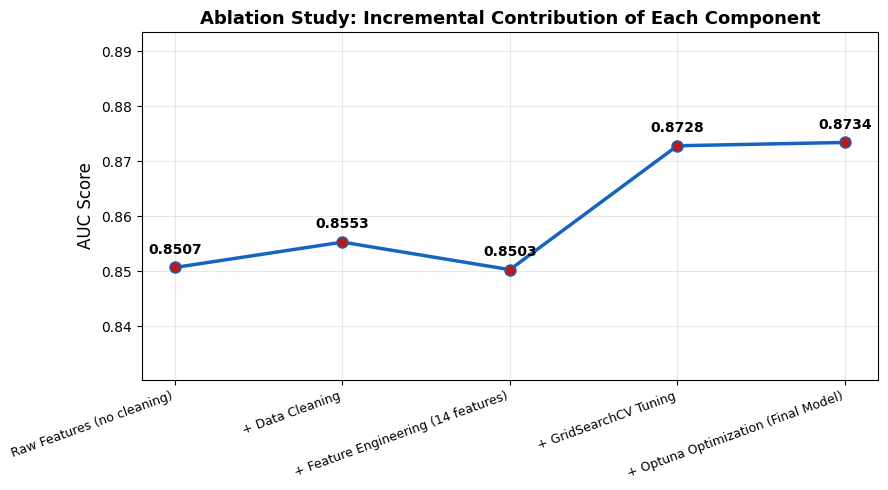

✅ Saved: figures/ablation_study.png


In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(ablation_df))
ax.plot(x, ablation_df['AUC'], marker='o', linewidth=2.5,
        color='#1565C0', markersize=8, markerfacecolor='#B71C1C')

for i, val in enumerate(ablation_df['AUC']):
    ax.annotate(f'{val:.4f}', (i, val), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(ablation_df['Experiment'], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_title('Ablation Study: Incremental Contribution of Each Component', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_ylim(min(ablation_df['AUC']) - 0.02, max(ablation_df['AUC']) + 0.02)
plt.tight_layout()
plt.savefig('../figures/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/ablation_study.png')

In [9]:
import pickle

with open('../models/best_params_optuna.pkl', 'rb') as f:
    best_params_all = pickle.load(f)

print(best_params_all)

{'Logistic Regression': {'C': 0.0192982820026737, 'solver': 'liblinear', 'penalty': 'l1'}, 'Random Forest': {'n_estimators': 172, 'max_depth': 9, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 'log2'}, 'Gradient Boosting': {'n_estimators': 508, 'learning_rate': 0.02077133354404949, 'max_depth': 5, 'subsample': 0.6779458726707359, 'min_samples_split': 19, 'max_features': 'log2'}, 'XGBoost': {'n_estimators': 388, 'learning_rate': 0.020967882837031732, 'max_depth': 4, 'subsample': 0.6379523960155078, 'colsample_bytree': 0.5378982092113247, 'min_child_weight': 3, 'gamma': 0.0629801893983079, 'reg_alpha': 0.003797162380239706, 'reg_lambda': 0.0018250345339827674}}


In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

best_xgb_params = best_params_all['XGBoost']

cv_model = XGBClassifier(
    **best_xgb_params,
    scale_pos_weight=scale_weight,
    eval_metric='logloss',
    verbosity=0,
    random_state=SEED,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_scores = cross_val_score(
    cv_model, X_train, y_train,
    cv=cv, scoring='roc_auc', n_jobs=-1
)

cv_results_df = pd.DataFrame({
    'Fold': [1, 2, 3, 4, 5],
    'AUC': np.round(cv_scores, 4)
})

mean_auc = cv_scores.mean()
std_auc  = cv_scores.std()

print('===== 5-FOLD CROSS-VALIDATION RESULTS (Best XGBoost) =====')
print(cv_results_df.to_string(index=False))
print(f'\nMean AUC : {mean_auc:.4f}')
print(f'Std  AUC : {std_auc:.4f}')
print(f'Result   : {mean_auc:.4f} ± {std_auc:.4f}')

cv_results_df.to_csv('../outputs/cv_results.csv', index=False)

import json
with open('../outputs/cv_summary.json', 'w') as f:
    json.dump({'mean_auc': float(mean_auc), 'std_auc': float(std_auc)}, f)

print('\n✅ Saved: outputs/cv_results.csv')

===== 5-FOLD CROSS-VALIDATION RESULTS (Best XGBoost) =====
 Fold    AUC
    1 0.8690
    2 0.8617
    3 0.8664
    4 0.8613
    5 0.8627

Mean AUC : 0.8642
Std  AUC : 0.0030
Result   : 0.8642 ± 0.0030

✅ Saved: outputs/cv_results.csv


In [13]:
from scipy.stats import wilcoxon
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# Build tuned models using their respective best Optuna params
lr_params = best_params_all['Logistic Regression']
rf_params = best_params_all['Random Forest']
gbm_params = best_params_all['Gradient Boosting']

models_for_cv = {
    'XGBoost': cv_model,  # already defined above

    'Logistic Regression': LogisticRegression(
        **lr_params, max_iter=1000, class_weight='balanced', random_state=SEED
    ),

    'Random Forest': RandomForestClassifier(
        **rf_params, class_weight='balanced', random_state=SEED, n_jobs=-1
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        **gbm_params, random_state=SEED
    )
}

cv_fold_scores = {}

for name, model in models_for_cv.items():
    X_data = X_train_scaled if name == 'Logistic Regression' else X_train
    scores = cross_val_score(model, X_data, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_fold_scores[name] = scores
    print(f'{name:25s}: {scores.round(4)}  Mean={scores.mean():.4f}')

# Wilcoxon test: XGBoost vs each other model
print('\n===== WILCOXON SIGNED-RANK TEST (XGBoost vs Others) =====')
wilcoxon_results = []

for name in ['Logistic Regression', 'Random Forest', 'Gradient Boosting']:
    stat, p_value = wilcoxon(cv_fold_scores['XGBoost'], cv_fold_scores[name])
    significance = 'Significant (p<0.05)' if p_value < 0.05 else 'Not Significant'
    wilcoxon_results.append({
        'Comparison': f'XGBoost vs {name}',
        'Statistic': round(stat, 4),
        'p-value': round(p_value, 4),
        'Result': significance
    })
    print(f'XGBoost vs {name:22s}: stat={stat:.4f}, p={p_value:.4f} -> {significance}')

wilcoxon_df = pd.DataFrame(wilcoxon_results)
wilcoxon_df.to_csv('../outputs/wilcoxon_test.csv', index=False)
print('\n✅ Saved: outputs/wilcoxon_test.csv')

XGBoost                  : [0.869  0.8617 0.8664 0.8613 0.8627]  Mean=0.8642
Logistic Regression      : [0.8629 0.855  0.8604 0.8563 0.859 ]  Mean=0.8587
Random Forest            : [0.8637 0.8571 0.8654 0.8593 0.8585]  Mean=0.8608
Gradient Boosting        : [0.8695 0.8609 0.8668 0.8622 0.8626]  Mean=0.8644

===== WILCOXON SIGNED-RANK TEST (XGBoost vs Others) =====
XGBoost vs Logistic Regression   : stat=0.0000, p=0.0625 -> Not Significant
XGBoost vs Random Forest         : stat=0.0000, p=0.0625 -> Not Significant
XGBoost vs Gradient Boosting     : stat=5.0000, p=0.6250 -> Not Significant

✅ Saved: outputs/wilcoxon_test.csv


Brier Score: 0.1400  (lower is better, 0 = perfect)


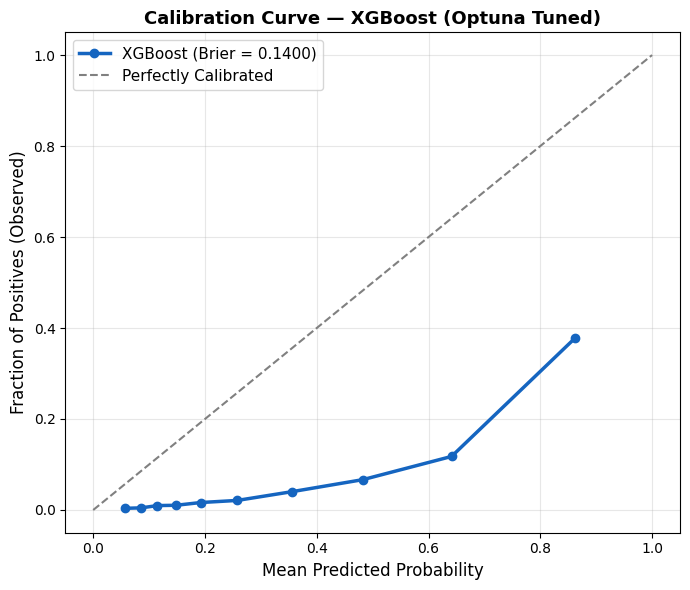

✅ Saved: figures/calibration_curve.png


In [14]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import pickle

# Load the final best model (XGBoost, Optuna tuned)
with open('../models/best_credit_model.pkl', 'rb') as f:
    final_model = pickle.load(f)

y_prob_test = final_model.predict_proba(X_test)[:, 1]

# Calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_prob_test, n_bins=10, strategy='quantile'
)

# Brier score
brier = brier_score_loss(y_test, y_prob_test)

print(f'Brier Score: {brier:.4f}  (lower is better, 0 = perfect)')

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mean_predicted_value, fraction_of_positives, marker='o', linewidth=2.5,
        color='#1565C0', label=f'XGBoost (Brier = {brier:.4f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives (Observed)', fontsize=12)
ax.set_title('Calibration Curve — XGBoost (Optuna Tuned)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Saved: figures/calibration_curve.png')

import json
with open('../outputs/brier_score.json', 'w') as f:
    json.dump({'brier_score': float(brier)}, f)

Before Calibration -> AUC: 0.8734, Brier: 0.1400
After  Calibration -> AUC: 0.8734, Brier: 0.0484


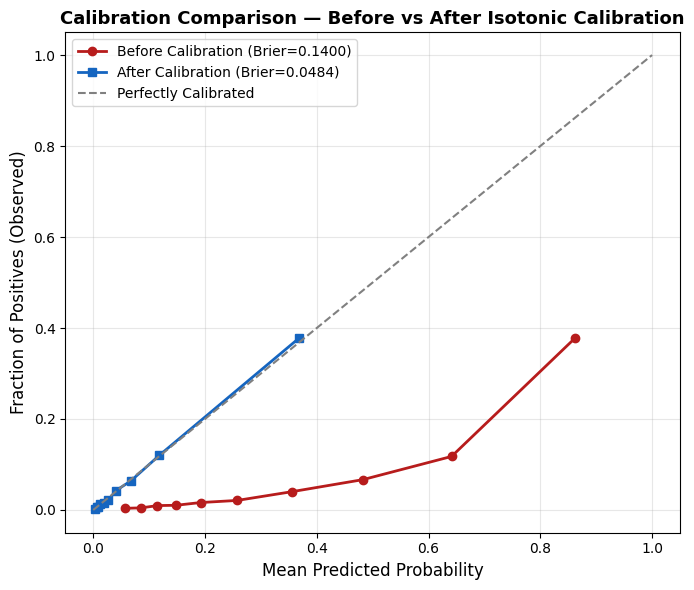

✅ Saved: figures/calibration_comparison.png


In [15]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score
import matplotlib.pyplot as plt

# Calibrate the existing best XGBoost model using isotonic regression
calibrated_model = CalibratedClassifierCV(final_model, method='isotonic', cv=5)
calibrated_model.fit(X_train, y_train)

y_prob_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

# Compare metrics
auc_calibrated = roc_auc_score(y_test, y_prob_calibrated)
brier_calibrated = brier_score_loss(y_test, y_prob_calibrated)

print(f'Before Calibration -> AUC: {roc_auc_score(y_test, y_prob_test):.4f}, Brier: {brier:.4f}')
print(f'After  Calibration -> AUC: {auc_calibrated:.4f}, Brier: {brier_calibrated:.4f}')

# Plot both curves together
frac_before, mean_before = calibration_curve(y_test, y_prob_test, n_bins=10, strategy='quantile')
frac_after, mean_after = calibration_curve(y_test, y_prob_calibrated, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mean_before, frac_before, marker='o', linewidth=2,
        color='#B71C1C', label=f'Before Calibration (Brier={brier:.4f})')
ax.plot(mean_after, frac_after, marker='s', linewidth=2,
        color='#1565C0', label=f'After Calibration (Brier={brier_calibrated:.4f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives (Observed)', fontsize=12)
ax.set_title('Calibration Comparison — Before vs After Isotonic Calibration', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/calibration_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

import json
with open('../outputs/calibration_comparison.json', 'w') as f:
    json.dump({
        'auc_before': float(roc_auc_score(y_test, y_prob_test)),
        'brier_before': float(brier),
        'auc_after': float(auc_calibrated),
        'brier_after': float(brier_calibrated)
    }, f)

print('✅ Saved: figures/calibration_comparison.png')

In [16]:
import pandas as pd
import numpy as np

# Predictions using the calibrated model (more reliable probabilities)
y_pred_final = calibrated_model.predict(X_test)

results_df = pd.DataFrame(X_test, columns=feature_names)
results_df['Actual']      = y_test
results_df['Predicted']   = y_pred_final
results_df['Probability'] = y_prob_calibrated

# Categorize errors
results_df['Error_Type'] = 'Correct'
results_df.loc[(results_df['Actual']==0) & (results_df['Predicted']==1), 'Error_Type'] = 'False Positive'
results_df.loc[(results_df['Actual']==1) & (results_df['Predicted']==0), 'Error_Type'] = 'False Negative'

fp = results_df[results_df['Error_Type']=='False Positive']
fn = results_df[results_df['Error_Type']=='False Negative']
correct = results_df[results_df['Error_Type']=='Correct']

print(f'Total Test Samples : {len(results_df):,}')
print(f'Correct Predictions: {len(correct):,} ({len(correct)/len(results_df)*100:.2f}%)')
print(f'False Positives    : {len(fp):,} ({len(fp)/len(results_df)*100:.2f}%)')
print(f'False Negatives    : {len(fn):,} ({len(fn)/len(results_df)*100:.2f}%)')

# Compare key feature averages: FN (missed defaults) vs Correctly identified defaults
key_features = ['RevolvingUtilizationOfUnsecuredLines', 'TotalTimesPastDue',
                 'WeightedLatePay', 'age', 'DebtRatio', 'NumberOfOpenCreditLinesAndLoans']

correct_defaults = results_df[(results_df['Actual']==1) & (results_df['Predicted']==1)]

comparison = pd.DataFrame({
    'Feature': key_features,
    'False Negative (Missed Default) Mean': [fn[f].mean() for f in key_features],
    'Correctly Identified Default Mean': [correct_defaults[f].mean() for f in key_features],
    'False Positive (Wrongly Flagged) Mean': [fp[f].mean() for f in key_features]
})
comparison = comparison.round(3)

print('\n===== ERROR ANALYSIS: FEATURE COMPARISON =====')
print(comparison.to_string(index=False))

comparison.to_csv('../outputs/error_analysis.csv', index=False)
print('\n✅ Saved: outputs/error_analysis.csv')

Total Test Samples : 29,998
Correct Predictions: 28,130 (93.77%)
False Positives    : 241 (0.80%)
False Negatives    : 1,627 (5.42%)

===== ERROR ANALYSIS: FEATURE COMPARISON =====
                             Feature  False Negative (Missed Default) Mean  Correctly Identified Default Mean  False Positive (Wrongly Flagged) Mean
RevolvingUtilizationOfUnsecuredLines                                 0.628                              0.942                                  0.913
                   TotalTimesPastDue                                 1.406                              7.003                                  6.062
                     WeightedLatePay                                 2.345                             14.116                                 12.046
                                 age                                46.096                             43.770                                 43.498
                           DebtRatio                               287.978